# Analisis Exploratorio de Datos (EDA) - Dataset Innovi

**Proyecto**: TFM - Productividad de Vinedos  
**Dataset**: `innovi_dataset_processed.csv`  
**Fecha**: 2026-03-06

---

## Indice
1. Carga y descripcion general del dataset
2. Calidad de datos y valores faltantes
3. Analisis temporal: produccion y rendimiento por campana
4. Distribucion espacial: provincias y municipios
5. Analisis de rendimiento (yield_kg_ha)
6. Analisis de grado alcoholico
7. Relacion superficie - produccion
8. Estacionalidad de la vendimia
9. Deteccion de outliers
10. Matriz de correlaciones
11. Resumen de insights clave

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

DATA_PATH = Path('../data/datasets/raw/innovi_dataset_processed.csv')
OUTPUT_DIR = Path('../docs/plans')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carga y Descripcion General

In [2]:
df = pd.read_csv(DATA_PATH)
df['harvest_date'] = pd.to_datetime(df['harvest_date'])
df['harvest_month'] = df['harvest_date'].dt.month
df['harvest_doy'] = df['harvest_date'].dt.dayofyear

# Mapeo de codigos de provincia a nombres
PROV_MAP = {'[43]': 'Tarragona', '[8]': 'Barcelona', '[17]': 'Girona', '[]': 'Desconocida'}
df['provincia_nombre'] = df['province'].map(PROV_MAP)

# Flag multi-parcela
df['is_multi_plot'] = df['place_id'].str.contains(',')

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Parcelas unicas (place_id): {df['place_id'].nunique():,}")
print(f"Rango temporal: {df['year'].min()} - {df['year'].max()}")
print(f"Rango fechas vendimia: {df['harvest_date'].min().date()} a {df['harvest_date'].max().date()}")
print(f"\nColumnas:")
for c in df.columns:
    print(f"  {c}: {df[c].dtype}")

Dimensiones: 12,079 filas x 19 columnas
Parcelas unicas (place_id): 3,609
Rango temporal: 2020 - 2025
Rango fechas vendimia: 2020-09-10 a 2025-09-09

Columnas:
  place_id: object
  year: int64
  harvest_date: datetime64[ns]
  province: object
  municipality: object
  polygon: object
  parcel: object
  enclosure: object
  total_enclosures: int64
  declared_area_ha: float64
  area_ha: float64
  production_kg: int64
  yield_kg_ha: float64
  alcohol_degree: float64
  geometry: object
  harvest_month: int32
  harvest_doy: int32
  provincia_nombre: object
  is_multi_plot: bool


In [4]:
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
year,12079.0,2022.75,2020.0,2021.0,2023.0,2024.0,2025.0,1.51
harvest_date,12079,2023-06-06 01:36:05.245467392,2020-09-10 00:00:00,2021-10-07 00:00:00,2023-08-28 00:00:00,2024-09-07 00:00:00,2025-09-09 00:00:00,NaN
total_enclosures,12079.0,1.68,0.0,1.0,1.0,2.0,23.0,1.31
declared_area_ha,12079.0,0.71,0.0,0.36,0.57,0.91,10.08,0.57
area_ha,11970.0,1.24,0.01,0.63,1.0,1.58,18.28,1.01
production_kg,12079.0,5320.8,0.0,2280.0,4025.0,6940.0,85660.0,4749.73
yield_kg_ha,11970.0,5745.81,0.0,2618.92,4341.57,5831.11,884468.22,17726.69
alcohol_degree,12079.0,12.32,1.0,11.0,12.13,13.7,19.2,1.85
harvest_month,12079.0,8.65,3.0,8.0,9.0,9.0,12.0,0.54
harvest_doy,12079.0,248.71,88.0,240.0,248.0,257.0,363.0,12.32


## 2. Calidad de Datos y Valores Faltantes

In [5]:
# Valores nulos
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, 'Porcentaje (%)': null_pct})
null_df = null_df[null_df['Nulos'] > 0]
print("Columnas con valores nulos:")
display(null_df)

# Registros multi-parcela
multi_pct = df['is_multi_plot'].sum() / len(df) * 100
print(f"\nRegistros multi-parcela (place_id con coma): {df['is_multi_plot'].sum():,} ({multi_pct:.1f}%)")

# Produccion = 0
zero_prod = (df['production_kg'] == 0).sum()
print(f"Registros con produccion = 0 kg: {zero_prod} ({zero_prod/len(df)*100:.2f}%)")

# Yield extremos
print(f"Registros con yield > 20,000 kg/ha: {(df['yield_kg_ha'] > 20000).sum()}")
print(f"Registros con yield > 50,000 kg/ha: {(df['yield_kg_ha'] > 50000).sum()}")

Columnas con valores nulos:


,Nulos,Porcentaje (%)
area_ha,109,0.9
yield_kg_ha,109,0.9
geometry,109,0.9



Registros multi-parcela (place_id con coma): 4,386 (36.3%)
Registros con produccion = 0 kg: 2 (0.02%)
Registros con yield > 20,000 kg/ha: 217
Registros con yield > 50,000 kg/ha: 48


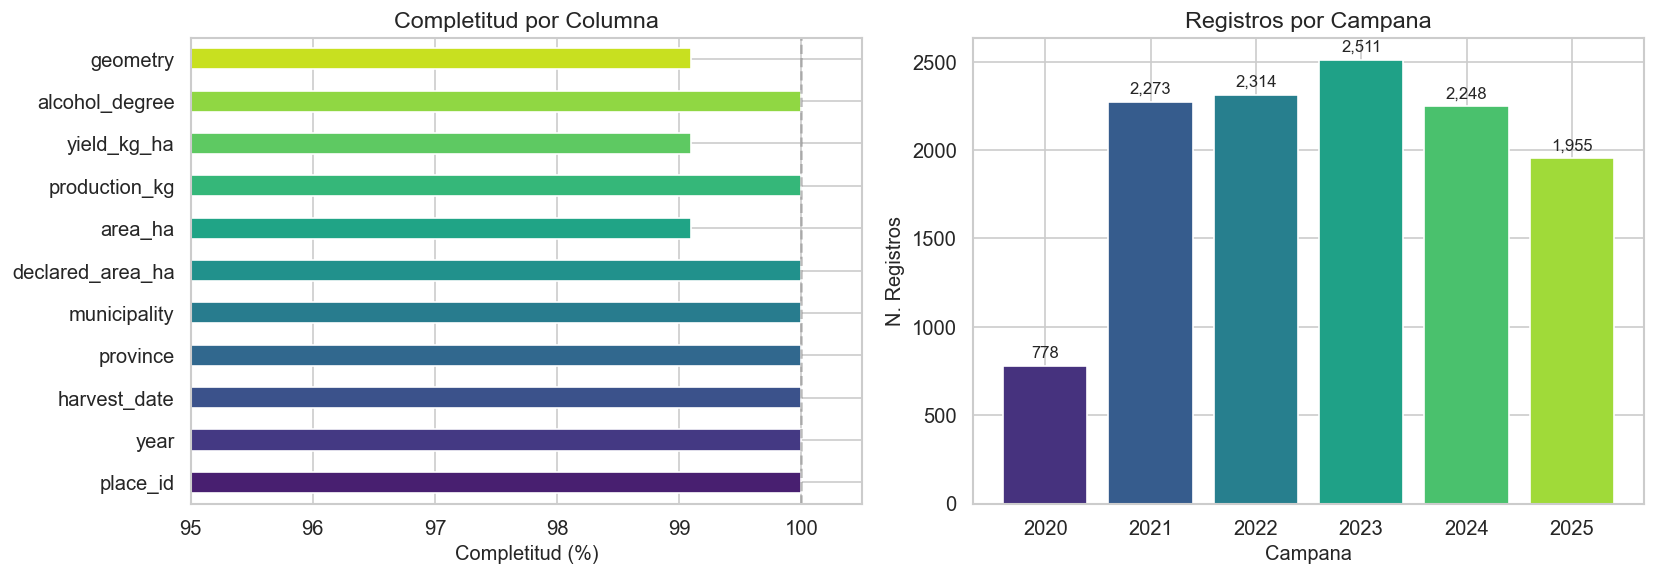

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Completitud por columna
completeness = ((1 - df.isnull().mean()) * 100)
cols_to_show = ['place_id','year','harvest_date','province','municipality',
                'declared_area_ha','area_ha','production_kg','yield_kg_ha',
                'alcohol_degree','geometry']
completeness[cols_to_show].plot.barh(ax=axes[0], color=sns.color_palette('viridis', len(cols_to_show)))
axes[0].set_xlabel('Completitud (%)')
axes[0].set_title('Completitud por Columna')
axes[0].set_xlim(95, 100.5)
axes[0].axvline(100, color='gray', linestyle='--', alpha=0.5)

# Registros por anio
year_counts = df['year'].value_counts().sort_index()
bars = axes[1].bar(year_counts.index, year_counts.values, color=sns.color_palette('viridis', len(year_counts)))
axes[1].set_xlabel('Campana')
axes[1].set_ylabel('N. Registros')
axes[1].set_title('Registros por Campana')
for bar, v in zip(bars, year_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 30, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig01_calidad_datos.png', bbox_inches='tight')
plt.show()

## 3. Analisis Temporal: Produccion y Rendimiento por Campana

In [7]:
# Estadisticas agregadas por campana
yearly = df.groupby('year').agg(
    n_registros=('place_id', 'count'),
    n_parcelas=('place_id', 'nunique'),
    produccion_total_kg=('production_kg', 'sum'),
    produccion_media_kg=('production_kg', 'mean'),
    yield_medio=('yield_kg_ha', 'mean'),
    yield_mediana=('yield_kg_ha', 'median'),
    grado_medio=('alcohol_degree', 'mean'),
    superficie_media_ha=('area_ha', 'mean')
).round(1)
display(yearly)

,n_registros,n_parcelas,produccion_total_kg,produccion_media_kg,yield_medio,yield_mediana,grado_medio,superficie_media_ha
year,,,,,,,,
2020,778,778,4169197,5358.9,6596.1,4249.5,14.3,1.2
2021,2273,2273,15883696,6988.0,8162.3,5334.3,12.1,1.3
2022,2314,2314,13700069,5920.5,6784.0,4804.0,12.4,1.3
2023,2511,2511,11606234,4622.2,4703.8,4079.4,12.3,1.2
2024,2248,2248,9049806,4025.7,4044.7,3511.0,12.0,1.2
2025,1955,1955,9860925,5044.0,4672.5,4475.3,12.1,1.3


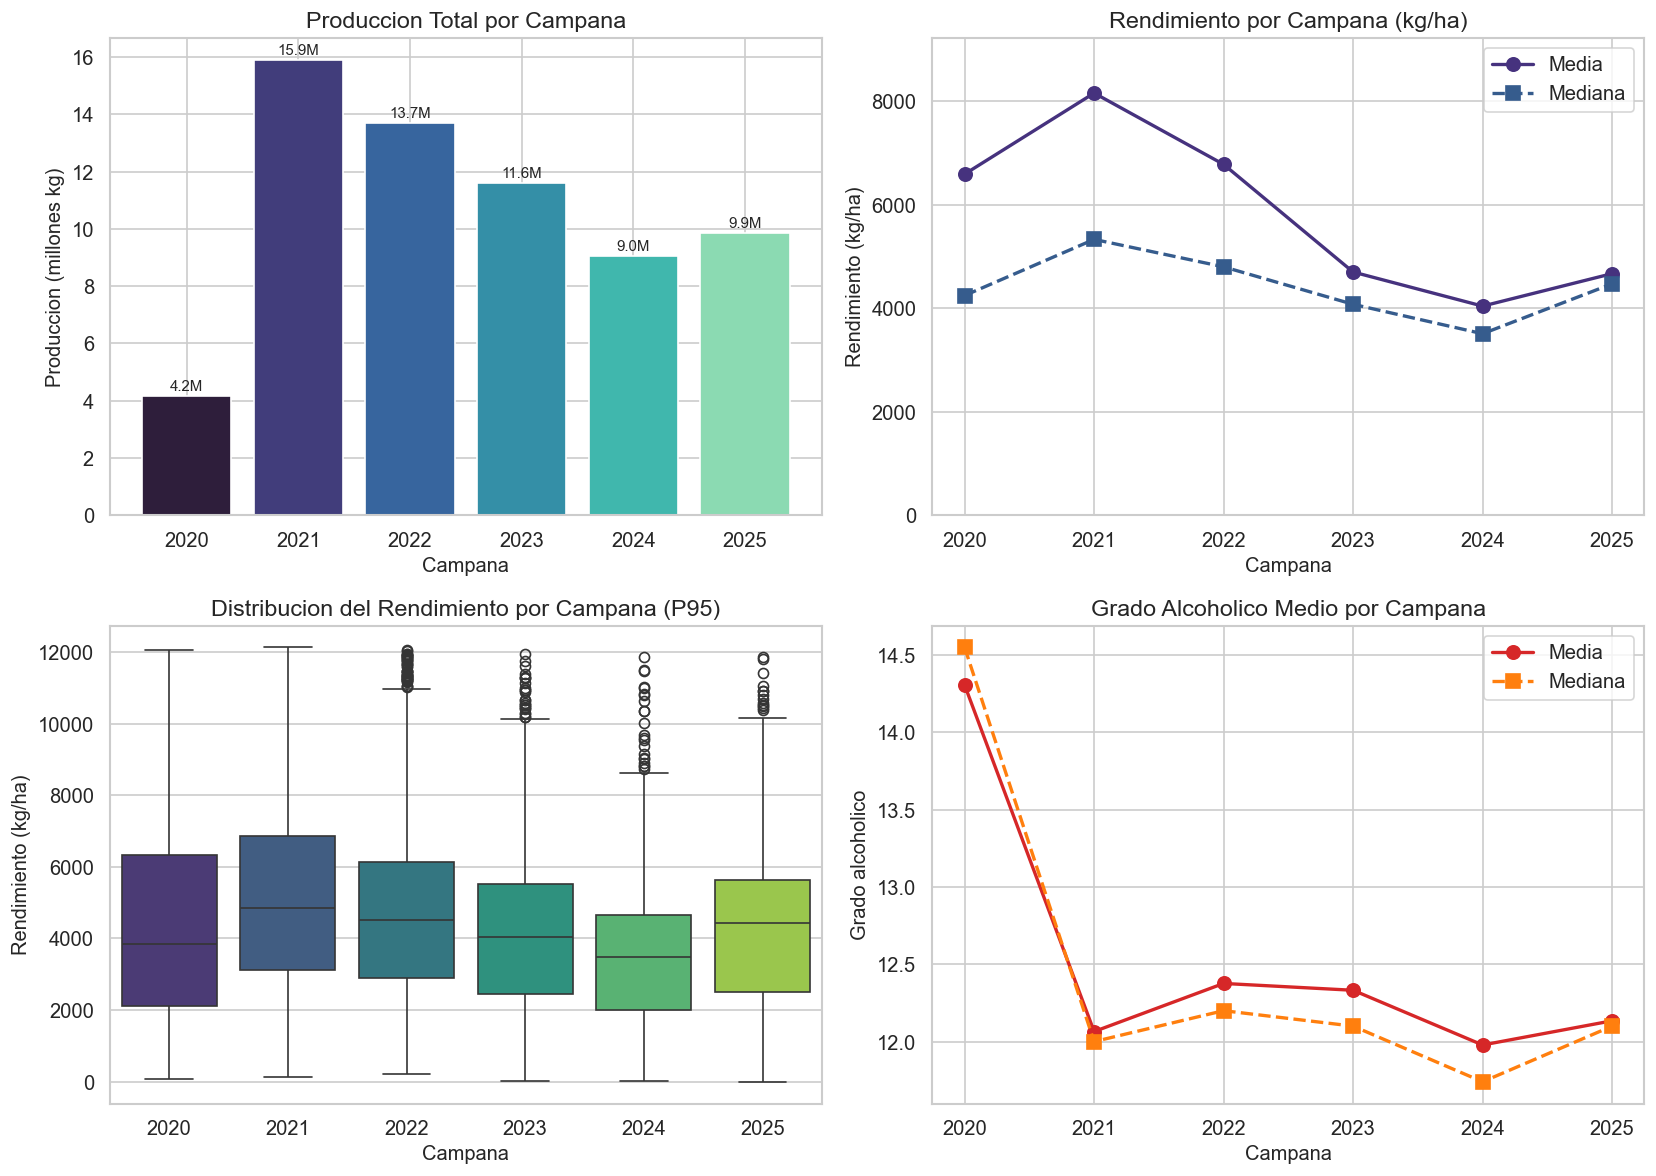

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3a. Produccion total por campana
ax = axes[0, 0]
prod_total = df.groupby('year')['production_kg'].sum() / 1e6
bars = ax.bar(prod_total.index, prod_total.values, color=sns.color_palette('mako', len(prod_total)))
ax.set_title('Produccion Total por Campana')
ax.set_ylabel('Produccion (millones kg)')
ax.set_xlabel('Campana')
for bar, v in zip(bars, prod_total.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, f'{v:.1f}M', ha='center', fontsize=9)

# 3b. Rendimiento medio y mediana por campana
ax = axes[0, 1]
yield_stats = df.groupby('year')['yield_kg_ha'].agg(['mean', 'median'])
ax.plot(yield_stats.index, yield_stats['mean'], 'o-', label='Media', linewidth=2, markersize=8)
ax.plot(yield_stats.index, yield_stats['median'], 's--', label='Mediana', linewidth=2, markersize=8)
ax.set_title('Rendimiento por Campana (kg/ha)')
ax.set_ylabel('Rendimiento (kg/ha)')
ax.set_xlabel('Campana')
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

# 3c. Boxplot rendimiento por campana
ax = axes[1, 0]
# Filtrar outliers extremos para mejor visualizacion
df_filt = df[df['yield_kg_ha'] <= df['yield_kg_ha'].quantile(0.95)]
sns.boxplot(data=df_filt, x='year', y='yield_kg_ha', ax=ax, palette='viridis')
ax.set_title('Distribucion del Rendimiento por Campana (P95)')
ax.set_ylabel('Rendimiento (kg/ha)')
ax.set_xlabel('Campana')

# 3d. Grado alcoholico medio por campana
ax = axes[1, 1]
grado_stats = df.groupby('year')['alcohol_degree'].agg(['mean', 'median'])
ax.plot(grado_stats.index, grado_stats['mean'], 'o-', label='Media', linewidth=2, markersize=8, color='#d62728')
ax.plot(grado_stats.index, grado_stats['median'], 's--', label='Mediana', linewidth=2, markersize=8, color='#ff7f0e')
ax.set_title('Grado Alcoholico Medio por Campana')
ax.set_ylabel('Grado alcoholico')
ax.set_xlabel('Campana')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig02_analisis_temporal.png', bbox_inches='tight')
plt.show()

## 4. Distribucion Espacial: Provincias y Municipios

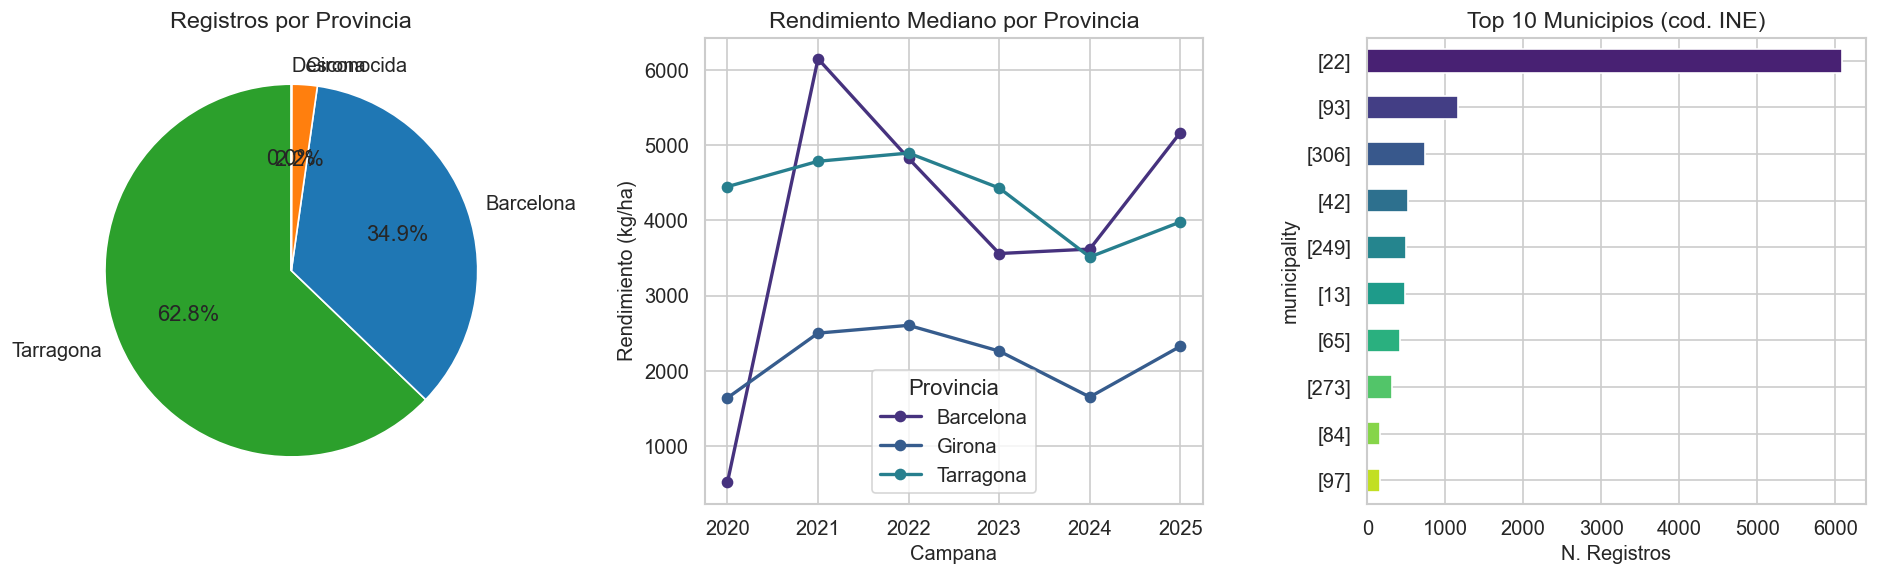

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4a. Registros por provincia
ax = axes[0]
prov_counts = df['provincia_nombre'].value_counts()
colors_prov = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
wedges, texts, autotexts = ax.pie(prov_counts.values, labels=prov_counts.index, 
                                   autopct='%1.1f%%', colors=colors_prov, startangle=90)
ax.set_title('Registros por Provincia')

# 4b. Rendimiento medio por provincia y campana
ax = axes[1]
prov_yield = df.groupby(['year', 'provincia_nombre'])['yield_kg_ha'].median().unstack()
prov_yield.drop(columns='Desconocida', errors='ignore').plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Rendimiento Mediano por Provincia')
ax.set_ylabel('Rendimiento (kg/ha)')
ax.set_xlabel('Campana')
ax.legend(title='Provincia')

# 4c. Top 10 municipios por n registros
ax = axes[2]
top_muni = df['municipality'].value_counts().head(10)
top_muni.plot.barh(ax=ax, color=sns.color_palette('viridis', 10))
ax.set_xlabel('N. Registros')
ax.set_title('Top 10 Municipios (cod. INE)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig03_distribucion_espacial.png', bbox_inches='tight')
plt.show()

In [10]:
# Tabla resumen por provincia
prov_summary = df.groupby('provincia_nombre').agg(
    registros=('place_id', 'count'),
    parcelas_unicas=('place_id', 'nunique'),
    prod_total_ton=('production_kg', lambda x: x.sum() / 1000),
    yield_mediana=('yield_kg_ha', 'median'),
    grado_medio=('alcohol_degree', 'mean'),
    sup_media_ha=('area_ha', 'mean')
).round(1)
display(prov_summary)

,registros,parcelas_unicas,prod_total_ton,yield_mediana,grado_medio,sup_media_ha
provincia_nombre,,,,,,
Barcelona,4221,1407,24963.6,4521.2,10.8,1.4
Desconocida,3,3,27.9,NaN,11.1,NaN
Girona,267,78,1353.0,2229.1,13.6,2.3
Tarragona,7588,2121,37925.5,4331.4,13.1,1.1


## 5. Analisis de Rendimiento (yield_kg_ha)

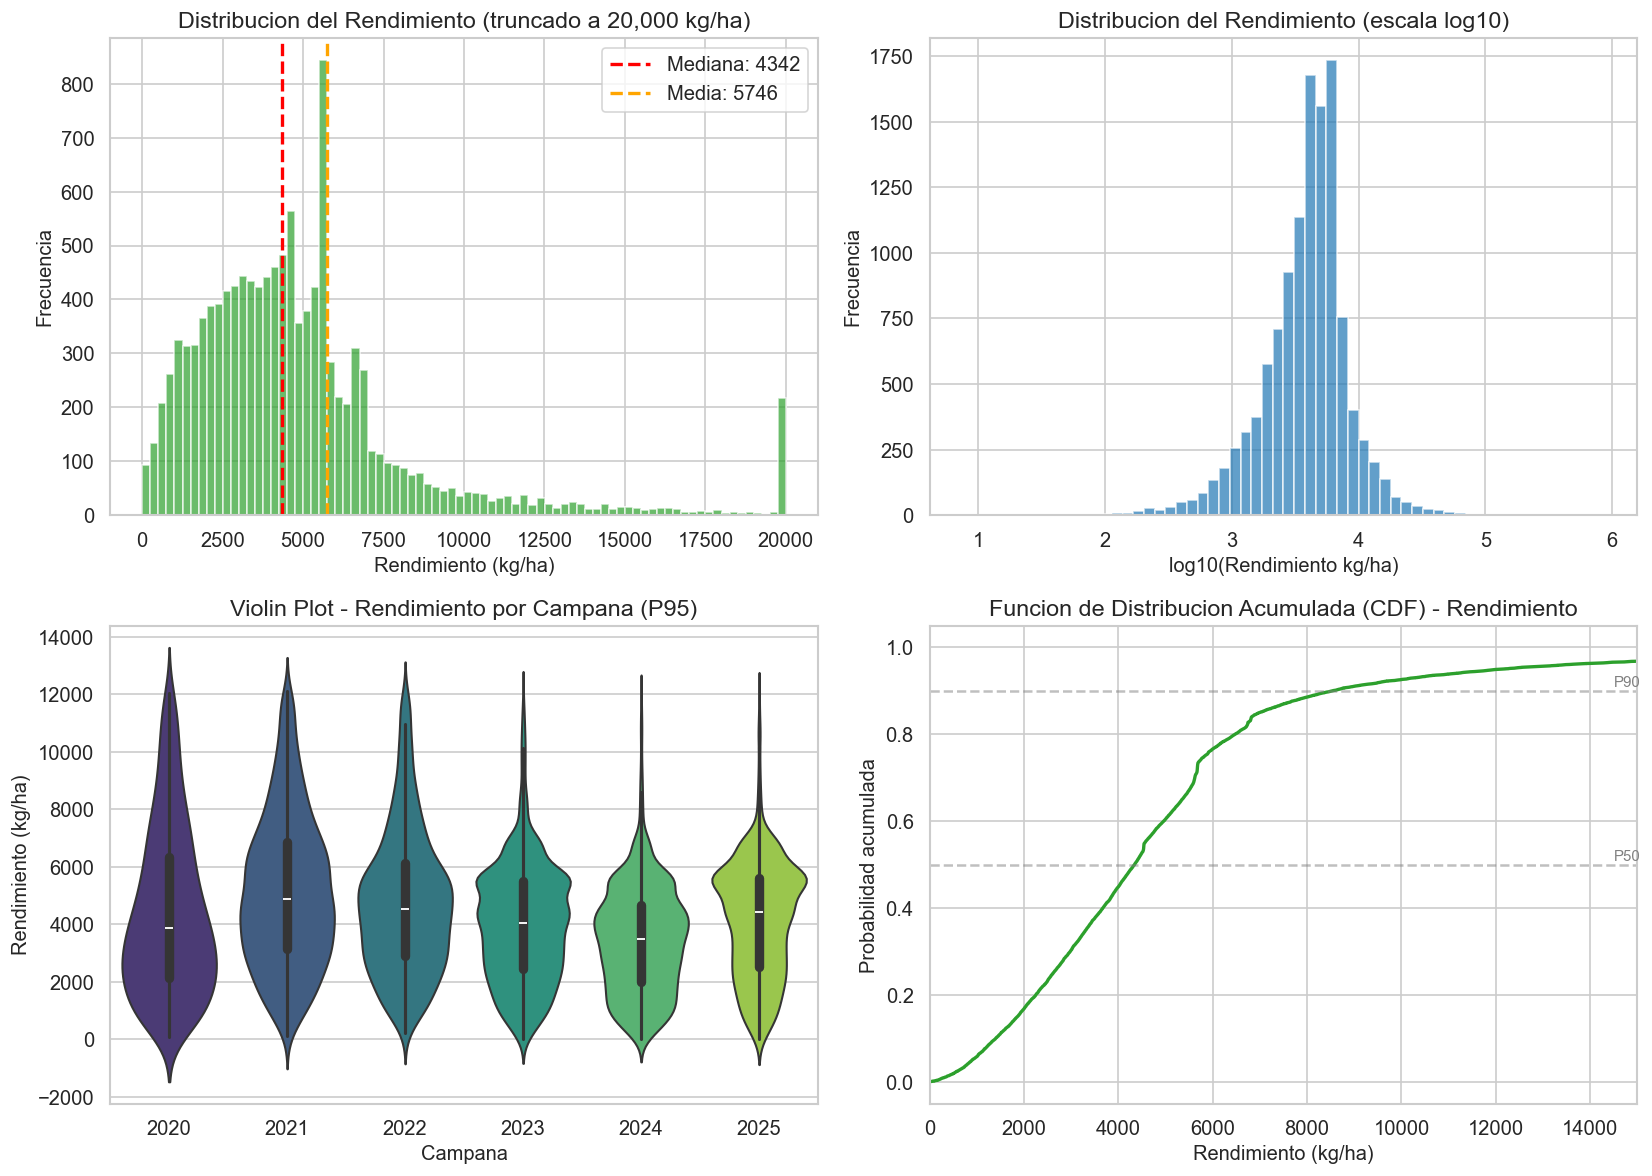

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5a. Histograma de rendimiento
ax = axes[0, 0]
df_valid = df[df['yield_kg_ha'].notna() & (df['yield_kg_ha'] > 0)]
df_valid['yield_kg_ha'].clip(upper=20000).hist(bins=80, ax=ax, color='#2ca02c', alpha=0.7, edgecolor='white')
ax.axvline(df_valid['yield_kg_ha'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {df_valid["yield_kg_ha"].median():.0f}')
ax.axvline(df_valid['yield_kg_ha'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Media: {df_valid["yield_kg_ha"].mean():.0f}')
ax.set_title('Distribucion del Rendimiento (truncado a 20,000 kg/ha)')
ax.set_xlabel('Rendimiento (kg/ha)')
ax.set_ylabel('Frecuencia')
ax.legend()

# 5b. Log-scale histogram
ax = axes[0, 1]
df_valid['yield_kg_ha'].apply(np.log10).hist(bins=60, ax=ax, color='#1f77b4', alpha=0.7, edgecolor='white')
ax.set_title('Distribucion del Rendimiento (escala log10)')
ax.set_xlabel('log10(Rendimiento kg/ha)')
ax.set_ylabel('Frecuencia')

# 5c. Violin plot por campana
ax = axes[1, 0]
df_violin = df_filt[df_filt['yield_kg_ha'] > 0].copy()
sns.violinplot(data=df_violin, x='year', y='yield_kg_ha', ax=ax, palette='viridis', inner='box')
ax.set_title('Violin Plot - Rendimiento por Campana (P95)')
ax.set_ylabel('Rendimiento (kg/ha)')
ax.set_xlabel('Campana')

# 5d. CDF del rendimiento
ax = axes[1, 1]
sorted_yield = np.sort(df_valid['yield_kg_ha'].values)
cdf = np.arange(1, len(sorted_yield) + 1) / len(sorted_yield)
ax.plot(sorted_yield, cdf, linewidth=2, color='#2ca02c')
ax.set_xlim(0, 15000)
ax.set_title('Funcion de Distribucion Acumulada (CDF) - Rendimiento')
ax.set_xlabel('Rendimiento (kg/ha)')
ax.set_ylabel('Probabilidad acumulada')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
ax.text(14500, 0.51, 'P50', fontsize=9, color='gray')
ax.text(14500, 0.91, 'P90', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig04_analisis_rendimiento.png', bbox_inches='tight')
plt.show()

## 6. Analisis de Grado Alcoholico

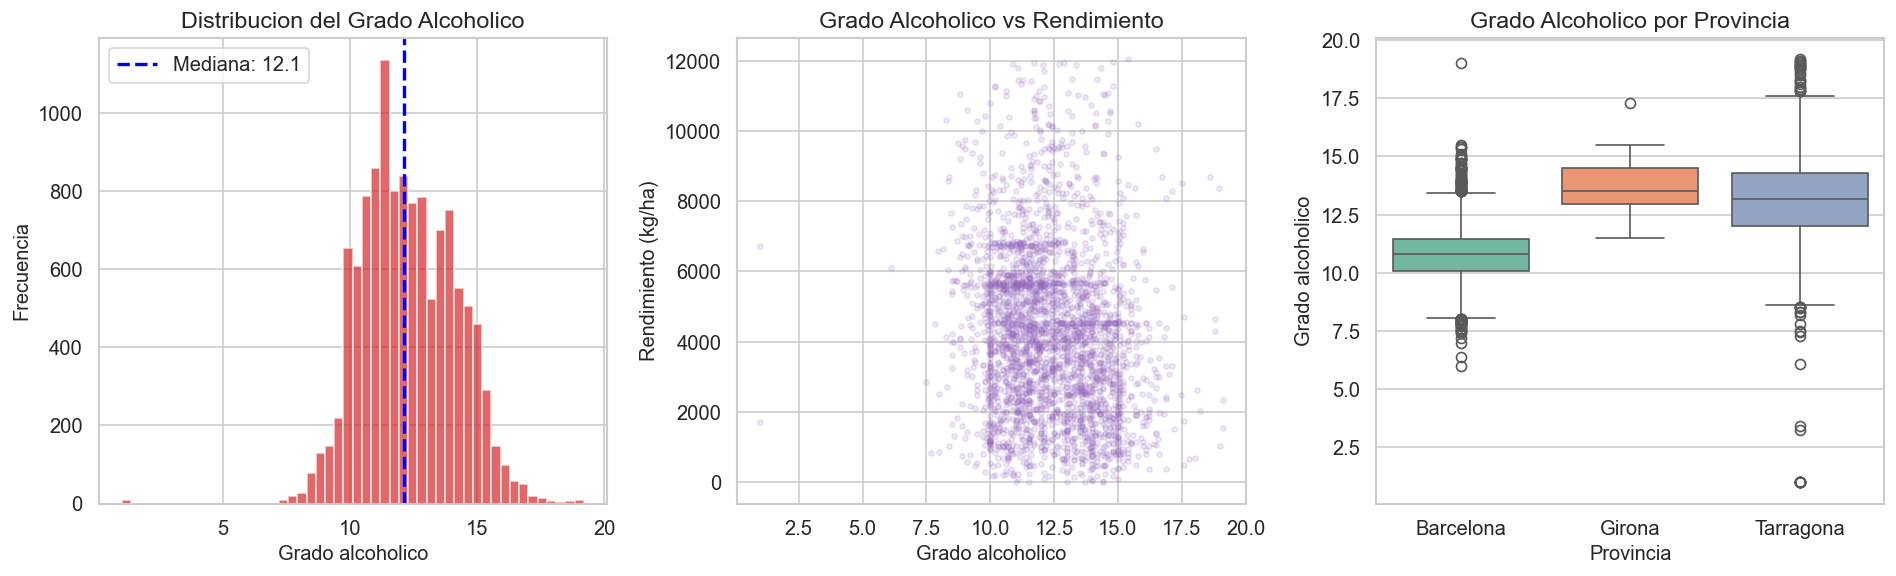

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Histograma de grado alcoholico
ax = axes[0]
df['alcohol_degree'].hist(bins=50, ax=ax, color='#d62728', alpha=0.7, edgecolor='white')
ax.axvline(df['alcohol_degree'].median(), color='blue', linestyle='--', linewidth=2, 
           label=f'Mediana: {df["alcohol_degree"].median():.1f}')
ax.set_title('Distribucion del Grado Alcoholico')
ax.set_xlabel('Grado alcoholico')
ax.set_ylabel('Frecuencia')
ax.legend()

# 6b. Grado vs Rendimiento (scatter)
ax = axes[1]
sample = df_filt.sample(min(3000, len(df_filt)), random_state=42)
ax.scatter(sample['alcohol_degree'], sample['yield_kg_ha'], alpha=0.15, s=10, color='#9467bd')
ax.set_title('Grado Alcoholico vs Rendimiento')
ax.set_xlabel('Grado alcoholico')
ax.set_ylabel('Rendimiento (kg/ha)')

# 6c. Boxplot grado por provincia
ax = axes[2]
df_prov = df[df['provincia_nombre'] != 'Desconocida']
sns.boxplot(data=df_prov, x='provincia_nombre', y='alcohol_degree', ax=ax, palette='Set2')
ax.set_title('Grado Alcoholico por Provincia')
ax.set_xlabel('Provincia')
ax.set_ylabel('Grado alcoholico')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig05_grado_alcoholico.png', bbox_inches='tight')
plt.show()

## 7. Relacion Superficie - Produccion

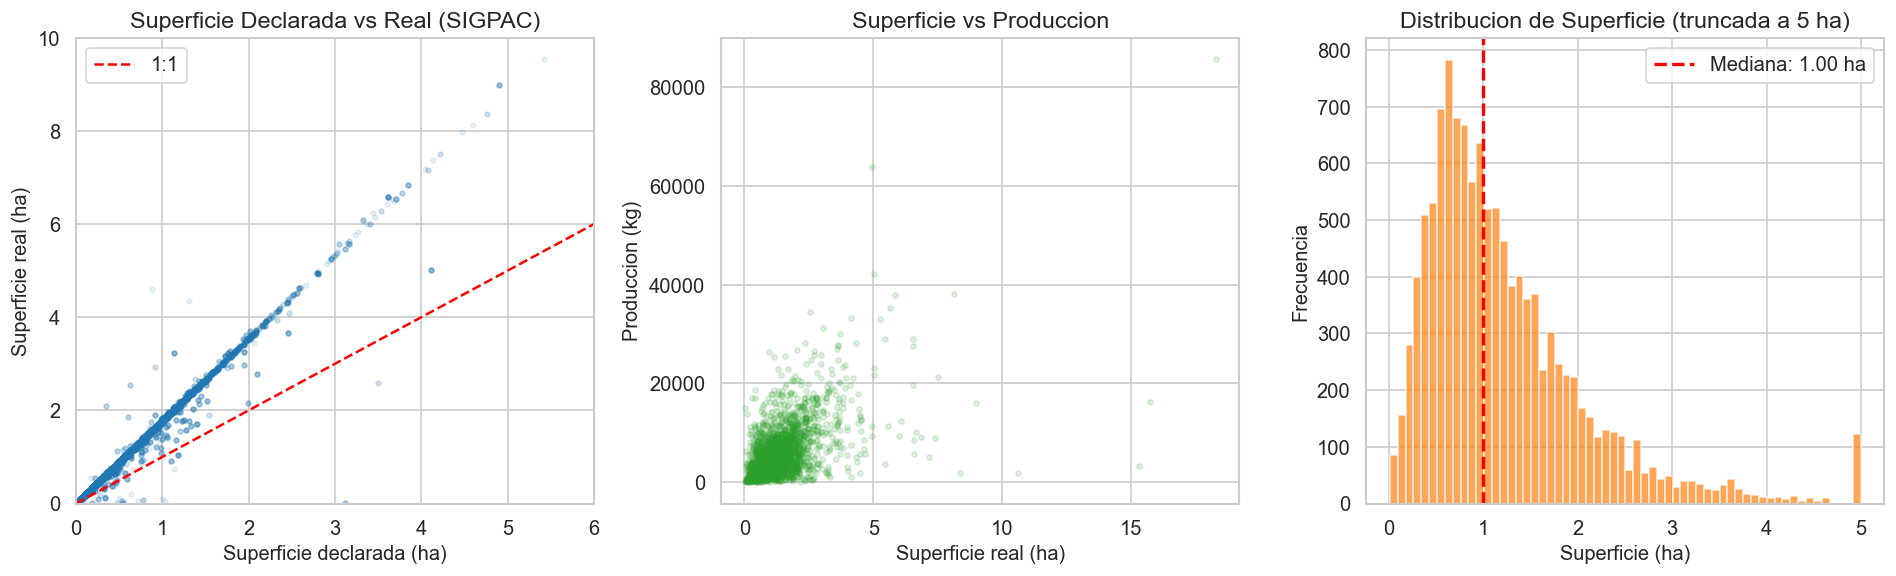

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7a. Superficie declarada vs real
ax = axes[0]
df_area = df.dropna(subset=['area_ha'])
ax.scatter(df_area['declared_area_ha'], df_area['area_ha'], alpha=0.1, s=8, color='#1f77b4')
max_val = max(df_area['declared_area_ha'].max(), df_area['area_ha'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='1:1')
ax.set_title('Superficie Declarada vs Real (SIGPAC)')
ax.set_xlabel('Superficie declarada (ha)')
ax.set_ylabel('Superficie real (ha)')
ax.legend()
ax.set_xlim(0, 6)
ax.set_ylim(0, 10)

# 7b. Superficie vs Produccion
ax = axes[1]
sample2 = df_area.sample(min(3000, len(df_area)), random_state=42)
ax.scatter(sample2['area_ha'], sample2['production_kg'], alpha=0.15, s=10, color='#2ca02c')
ax.set_title('Superficie vs Produccion')
ax.set_xlabel('Superficie real (ha)')
ax.set_ylabel('Produccion (kg)')

# 7c. Histograma de superficie
ax = axes[2]
df_area['area_ha'].clip(upper=5).hist(bins=60, ax=ax, color='#ff7f0e', alpha=0.7, edgecolor='white')
ax.axvline(df_area['area_ha'].median(), color='red', linestyle='--', linewidth=2,
           label=f'Mediana: {df_area["area_ha"].median():.2f} ha')
ax.set_title('Distribucion de Superficie (truncada a 5 ha)')
ax.set_xlabel('Superficie (ha)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig06_superficie_produccion.png', bbox_inches='tight')
plt.show()

## 8. Estacionalidad de la Vendimia

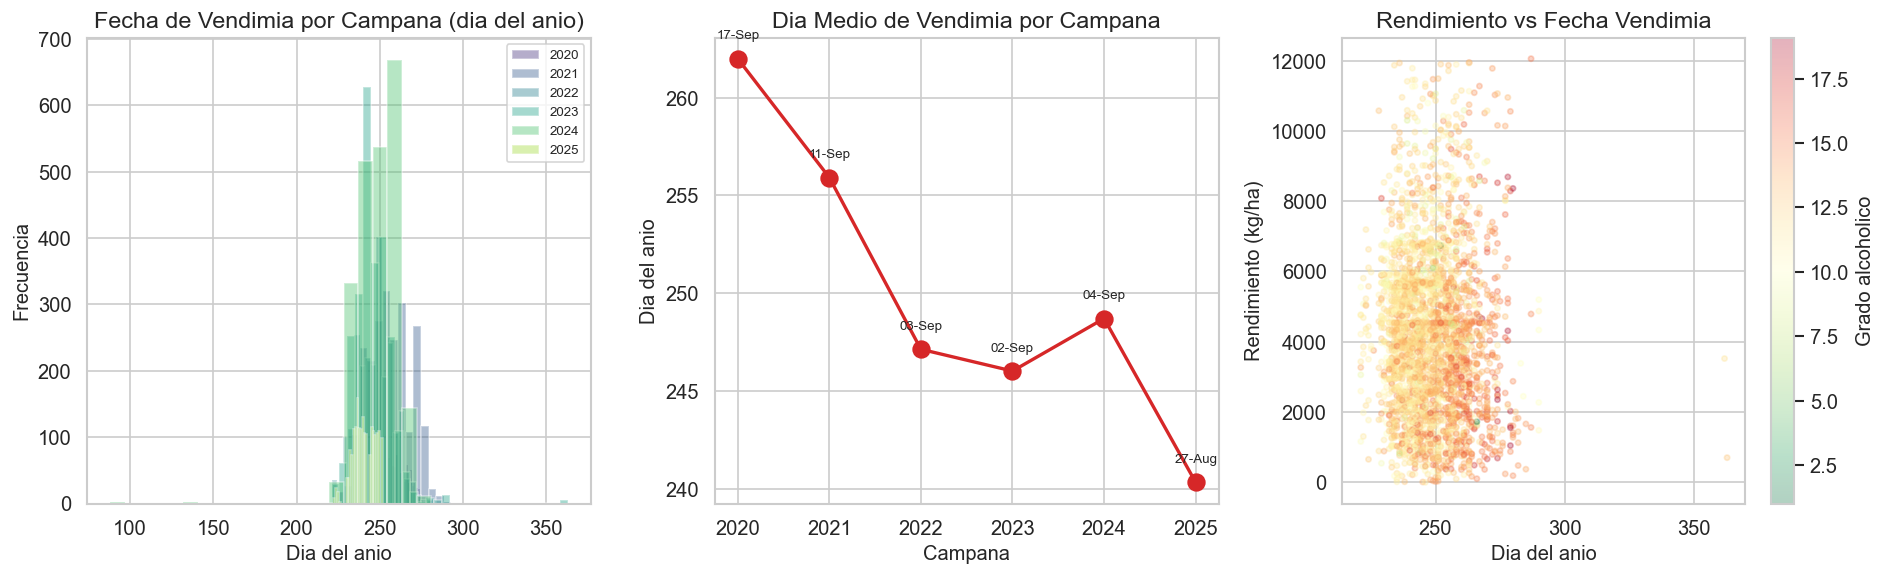

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 8a. Distribucion de fecha de vendimia (dia del anio)
ax = axes[0]
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    subset['harvest_doy'].hist(bins=30, ax=ax, alpha=0.4, label=str(year))
ax.set_title('Fecha de Vendimia por Campana (dia del anio)')
ax.set_xlabel('Dia del anio')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)

# 8b. Fecha media de vendimia por campana
ax = axes[1]
mean_doy = df.groupby('year')['harvest_doy'].mean()
ax.plot(mean_doy.index, mean_doy.values, 'o-', linewidth=2, markersize=10, color='#d62728')
ax.set_title('Dia Medio de Vendimia por Campana')
ax.set_xlabel('Campana')
ax.set_ylabel('Dia del anio')
# Anotaciones de fecha aproximada
for y, d in zip(mean_doy.index, mean_doy.values):
    import datetime
    approx_date = datetime.datetime(2024, 1, 1) + datetime.timedelta(days=int(d)-1)
    ax.annotate(approx_date.strftime('%d-%b'), (y, d), textcoords='offset points', 
                xytext=(0, 12), ha='center', fontsize=8)

# 8c. Rendimiento vs fecha de vendimia
ax = axes[2]
sample3 = df_filt.sample(min(3000, len(df_filt)), random_state=42)
sc = ax.scatter(sample3['harvest_doy'], sample3['yield_kg_ha'], 
                c=sample3['alcohol_degree'], cmap='RdYlGn_r', alpha=0.3, s=10)
plt.colorbar(sc, ax=ax, label='Grado alcoholico')
ax.set_title('Rendimiento vs Fecha Vendimia')
ax.set_xlabel('Dia del anio')
ax.set_ylabel('Rendimiento (kg/ha)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig07_estacionalidad.png', bbox_inches='tight')
plt.show()

## 9. Deteccion de Outliers

In [15]:
# IQR method para rendimiento
Q1 = df['yield_kg_ha'].quantile(0.25)
Q3 = df['yield_kg_ha'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_yield = df[(df['yield_kg_ha'] < lower) | (df['yield_kg_ha'] > upper)]
print(f"=== Outliers de Rendimiento (metodo IQR) ===")
print(f"Limites: [{lower:.0f}, {upper:.0f}] kg/ha")
print(f"Outliers: {len(outliers_yield):,} ({len(outliers_yield)/len(df)*100:.1f}%)")
print(f"  - Por debajo: {(df['yield_kg_ha'] < lower).sum()}")
print(f"  - Por arriba: {(df['yield_kg_ha'] > upper).sum()}")

# Area mismatch
df_area_check = df.dropna(subset=['area_ha'])
ratio = df_area_check['area_ha'] / df_area_check['declared_area_ha'].replace(0, np.nan)
area_mismatch = ((ratio > 3) | (ratio < 0.33)).sum()
print(f"\n=== Discrepancia superficie (ratio > 3x o < 0.33x) ===")
print(f"Registros con discrepancia: {area_mismatch} ({area_mismatch/len(df_area_check)*100:.1f}%)")

=== Outliers de Rendimiento (metodo IQR) ===
Limites: [-2199, 10649] kg/ha
Outliers: 774 (6.4%)
  - Por debajo: 0
  - Por arriba: 774

=== Discrepancia superficie (ratio > 3x o < 0.33x) ===
Registros con discrepancia: 46 (0.4%)


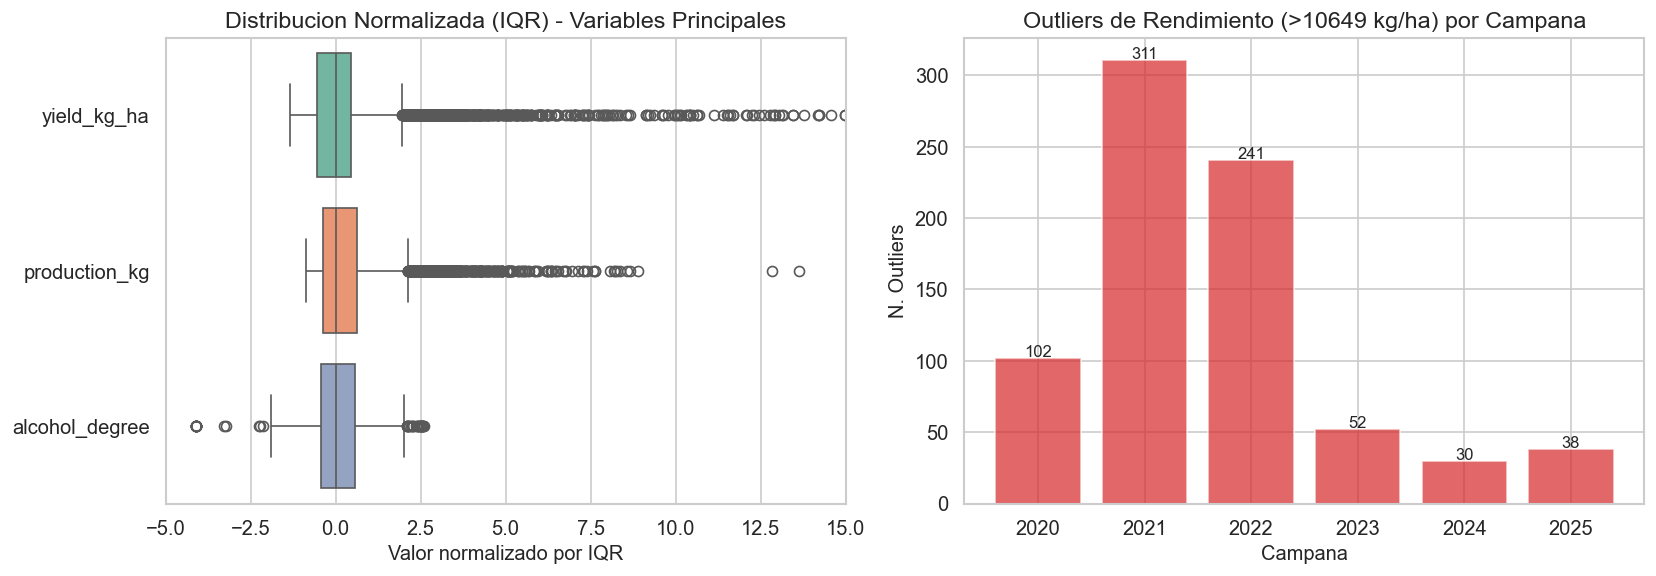

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 9a. Boxplot variables principales
ax = axes[0]
cols_box = ['yield_kg_ha', 'production_kg', 'alcohol_degree']
# Normalizar para comparar
df_norm = df[cols_box].copy()
for c in cols_box:
    df_norm[c] = (df_norm[c] - df_norm[c].median()) / (df_norm[c].quantile(0.75) - df_norm[c].quantile(0.25))
sns.boxplot(data=df_norm, orient='h', ax=ax, palette='Set2')
ax.set_title('Distribucion Normalizada (IQR) - Variables Principales')
ax.set_xlabel('Valor normalizado por IQR')
ax.set_xlim(-5, 15)

# 9b. Yield extremos por campana
ax = axes[1]
outlier_by_year = df[df['yield_kg_ha'] > upper].groupby('year').size()
all_years = pd.Series(0, index=sorted(df['year'].unique()))
outlier_by_year = outlier_by_year.reindex(all_years.index, fill_value=0)
bars = ax.bar(outlier_by_year.index, outlier_by_year.values, color='#d62728', alpha=0.7)
ax.set_title(f'Outliers de Rendimiento (>{upper:.0f} kg/ha) por Campana')
ax.set_xlabel('Campana')
ax.set_ylabel('N. Outliers')
for bar, v in zip(bars, outlier_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig08_outliers.png', bbox_inches='tight')
plt.show()

## 10. Matriz de Correlaciones

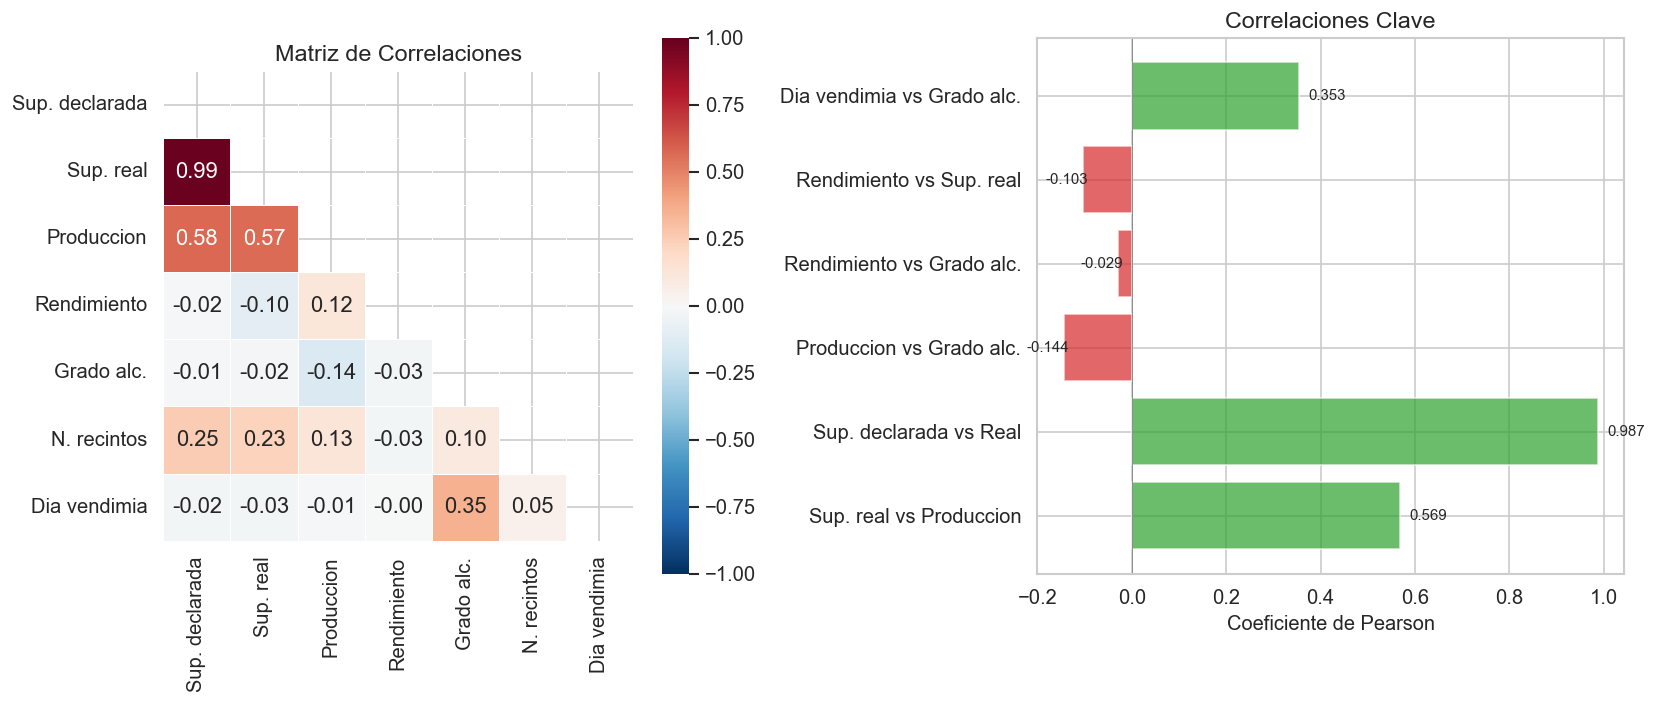

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 10a. Heatmap correlaciones
ax = axes[0]
numeric_cols = ['declared_area_ha', 'area_ha', 'production_kg', 'yield_kg_ha', 
                'alcohol_degree', 'total_enclosures', 'harvest_doy']
corr = df[numeric_cols].corr()
labels = ['Sup. declarada', 'Sup. real', 'Produccion', 'Rendimiento',
           'Grado alc.', 'N. recintos', 'Dia vendimia']
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels, ax=ax, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
ax.set_title('Matriz de Correlaciones')

# 10b. Pairplot de variables clave (sample)
ax = axes[1]
# Correlaciones mas relevantes
key_corrs = [
    ('Sup. real vs Produccion', corr.loc['area_ha', 'production_kg']),
    ('Sup. declarada vs Real', corr.loc['declared_area_ha', 'area_ha']),
    ('Produccion vs Grado alc.', corr.loc['production_kg', 'alcohol_degree']),
    ('Rendimiento vs Grado alc.', corr.loc['yield_kg_ha', 'alcohol_degree']),
    ('Rendimiento vs Sup. real', corr.loc['yield_kg_ha', 'area_ha']),
    ('Dia vendimia vs Grado alc.', corr.loc['harvest_doy', 'alcohol_degree']),
]
names, vals = zip(*key_corrs)
colors = ['#2ca02c' if v > 0 else '#d62728' for v in vals]
bars = ax.barh(range(len(names)), vals, color=colors, alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Coeficiente de Pearson')
ax.set_title('Correlaciones Clave')
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(v + 0.02 if v >= 0 else v - 0.08, bar.get_y() + bar.get_height()/2, 
            f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig09_correlaciones.png', bbox_inches='tight')
plt.show()

## 11. Analisis de Variabilidad Inter-anual por Parcela

In [18]:
# Parcelas con datos en multiples campanas
years_per_place = df.groupby('place_id')['year'].nunique()
print(f"Parcelas con datos en N campanas:")
print(years_per_place.value_counts().sort_index())

# CV (coeficiente de variacion) del rendimiento por parcela
places_multi = years_per_place[years_per_place >= 3].index
df_multi = df[df['place_id'].isin(places_multi)].copy()
cv_yield = df_multi.groupby('place_id')['yield_kg_ha'].agg(['mean', 'std'])
cv_yield['cv'] = cv_yield['std'] / cv_yield['mean'] * 100
cv_yield = cv_yield.dropna()

print(f"\nParcelas con >=3 campanas: {len(cv_yield)}")
print(f"CV medio del rendimiento: {cv_yield['cv'].median():.1f}%")
print(f"CV > 50%: {(cv_yield['cv'] > 50).sum()} parcelas ({(cv_yield['cv'] > 50).sum()/len(cv_yield)*100:.1f}%)")

Parcelas con datos en N campanas:
year
1    722
2    506
3    530
4    703
5    945
6    203
Name: count, dtype: int64

Parcelas con >=3 campanas: 2363
CV medio del rendimiento: 42.1%
CV > 50%: 862 parcelas (36.5%)


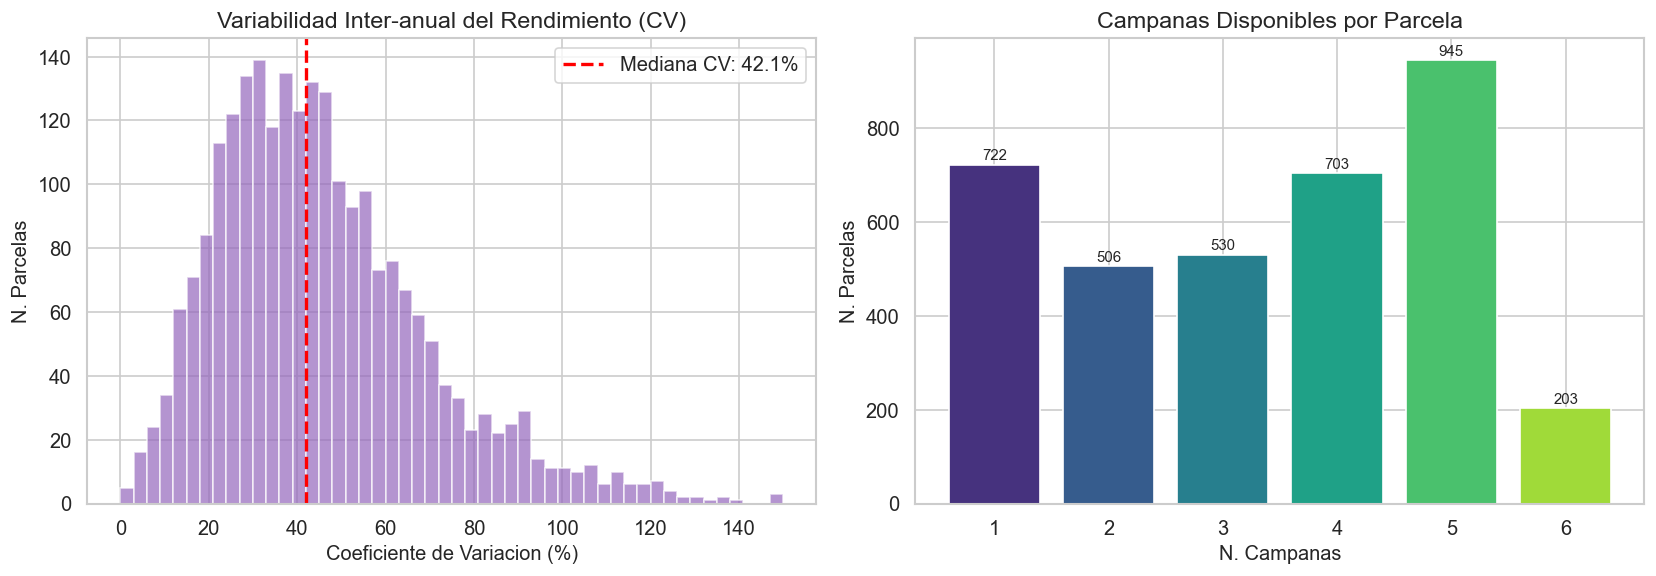

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 11a. Distribucion del CV
ax = axes[0]
cv_yield['cv'].clip(upper=150).hist(bins=50, ax=ax, color='#9467bd', alpha=0.7, edgecolor='white')
ax.axvline(cv_yield['cv'].median(), color='red', linestyle='--', linewidth=2,
           label=f'Mediana CV: {cv_yield["cv"].median():.1f}%')
ax.set_title('Variabilidad Inter-anual del Rendimiento (CV)')
ax.set_xlabel('Coeficiente de Variacion (%)')
ax.set_ylabel('N. Parcelas')
ax.legend()

# 11b. N campanas por parcela
ax = axes[1]
ypp = years_per_place.value_counts().sort_index()
bars = ax.bar(ypp.index, ypp.values, color=sns.color_palette('viridis', len(ypp)))
ax.set_title('Campanas Disponibles por Parcela')
ax.set_xlabel('N. Campanas')
ax.set_ylabel('N. Parcelas')
for bar, v in zip(bars, ypp.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig10_variabilidad.png', bbox_inches='tight')
plt.show()

## 12. Resumen de Insights Clave

### Dimension del dataset
- **12,079 registros** de produccion viticola correspondientes a **3,609 parcelas unicas**
- Cobertura temporal de **6 campanas** (2020-2025)
- Predominancia de **Tarragona (62.8%)** y **Barcelona (34.9%)**

### Produccion y rendimiento
- Rendimiento mediano: **~4,342 kg/ha**, con alta variabilidad (IQR: 2,619 - 5,831 kg/ha)
- **2023 fue la campana con menor produccion total**, con un descenso significativo respecto a 2021-2022
- Existe una **cola derecha larga** en la distribucion del rendimiento, con outliers que superan los 20,000 kg/ha

### Calidad (grado alcoholico)
- Grado alcoholico medio: **12.3**, con rango tipico 10-15
- **Correlacion negativa debil** entre produccion y grado alcoholico (r=-0.14): mayor produccion tiende a menor grado
- Tarragona presenta grado medio ligeramente superior a Barcelona

### Estacionalidad
- La vendimia se concentra en **agosto-septiembre** (97.5% de los registros)
- Existe variabilidad inter-anual en la fecha media de vendimia (~15 dias)

### Calidad de datos
- **99.1% de completitud** en todas las columnas (109 registros sin geometria/area)
- **36.3% de registros** corresponden a parcelas multi-ID (place_id con coma)
- ~1.8% de rendimientos son outliers extremos por el metodo IQR
- La superficie real (SIGPAC) tiende a ser **mayor** que la declarada

### Variabilidad inter-anual
- Las parcelas con >=3 campanas muestran un **CV mediano del rendimiento significativo**, indicando alta variabilidad natural en la produccion viticola
- Solo ~30% de las parcelas tienen datos en las 6 campanas completas

### Implicaciones para modelado
- Se recomienda **filtrar outliers extremos** (yield > 20,000 kg/ha) para modelos de prediccion
- La alta variabilidad inter-anual sugiere la importancia de **variables climaticas** como predictores
- Los registros multi-parcela requieren atencion especial al distribuir produccion entre IDs
- La discrepancia superficie declarada vs real indica la importancia de usar **area SIGPAC** como referencia